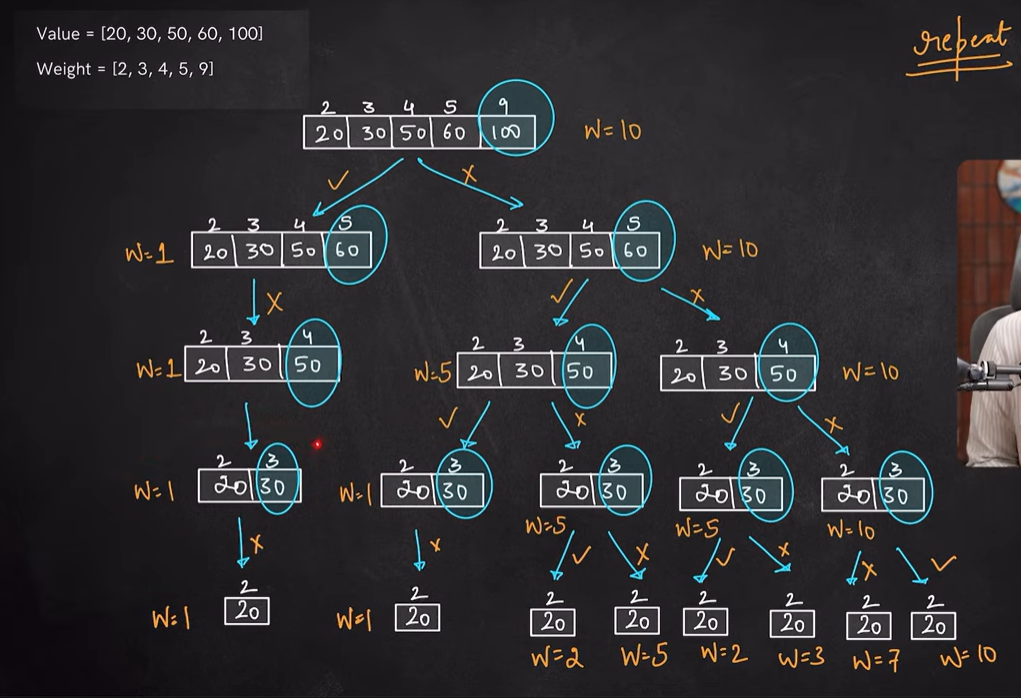
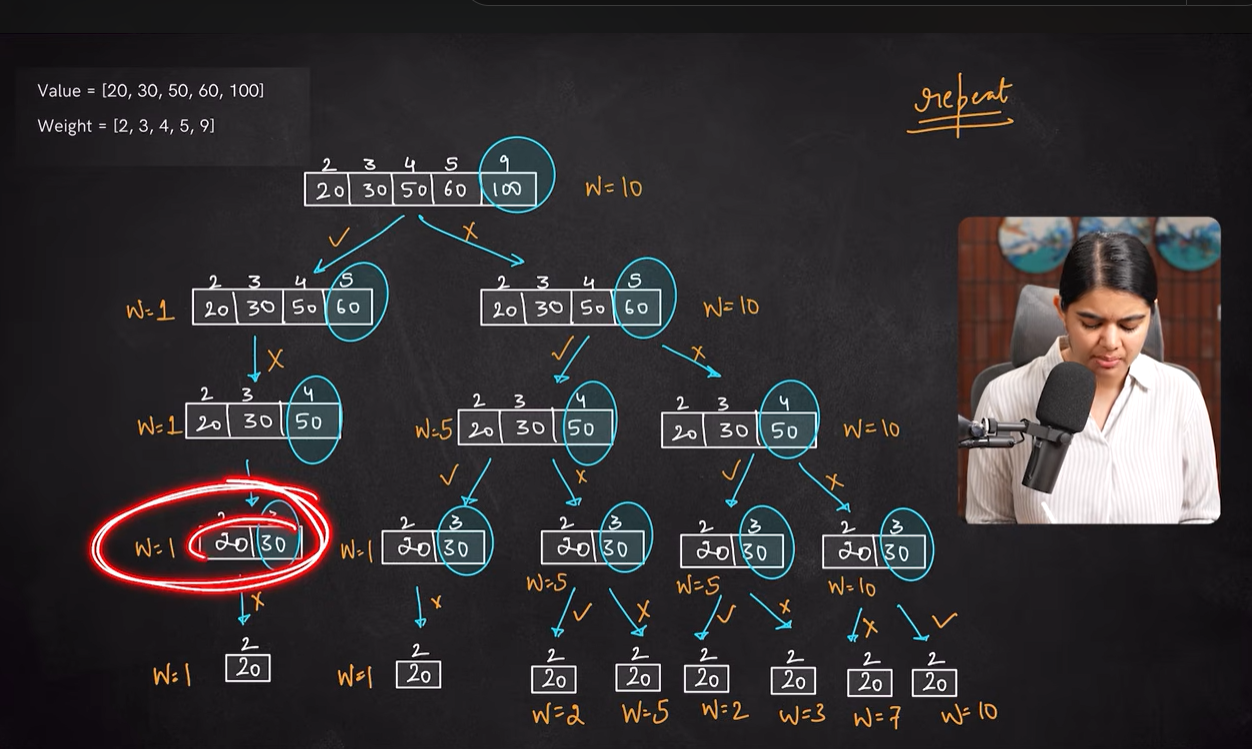

In [ ]:
def knapsack(items, W, n):
    if n == 0 or W == 0:
        return 0

    val = items[n - 1][0]
    wt = items[n - 1][1]
    # print(val)

    if wt <= W:
        include = val + knapsack(items, W - wt, n - 1)
        exclude = knapsack(items, W, n - 1)
        return max(include, exclude)
    else:
        return knapsack(items, W, n - 1)


items = [
    [5, 1],
    [3, 2],
    [9, 8],
    [16, 10]
]

C = 8

print(knapsack(items, C, len(items)))

5 5 8 9 9


# `1st Approach` : Memoization

In [16]:
def knapsack(items, W, n, dp):
    if n == 0 or W == 0:
        return 0

    if dp[n][W] != -1:
        return dp[n][W]

    val = items[n - 1][0]
    wt = items[n - 1][1]

    if wt <= W:
        include = val + knapsack(items, W - wt, n - 1, dp)
        exclude = knapsack(items, W, n - 1, dp)
        dp[n][W] = max(include, exclude)
    else:
        dp[n][W] = knapsack(items, W, n - 1, dp)

    return dp[n][W]


items = [
    [5, 1],
    [3, 2],
    [9, 8],
    [16, 10]
]

C = 8

dp = [[-1] * (C + 1) for _ in range(len(items) + 1)]

print(knapsack(items, C, len(items), dp))

9


# `Tabulation`

In [19]:
def knapsack(items, W, n):

    dp = [[0] * (W + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for j in range(1, W + 1):

            val = items[i - 1][0]
            wt = items[i - 1][1]

            if wt <= j:
                dp[i][j] = max(
                    val + dp[i - 1][j - wt],
                    dp[i - 1][j]
                )
            else:
                dp[i][j] = dp[i - 1][j]

    return dp[n][W]


items = [
    [5, 1],
    [3, 2],
    [9, 8],
    [16, 10]
]

C = 8

print(knapsack(items, C, len(items)))

9


In [ ]:
# TODO: Recursion TC :- O(2^n)
# SC :- O(n)
def profit(i,wt,val,C):
    if i == len(wt):
        return 0
    
    skip = profit(i + 1,wt,val,C)

    if wt[i] > C:
        return skip
    
    pick = val[i] + profit(i + 1,wt,val,C-wt[i])
    return max(pick,skip)  

In [2]:
val = [5,3,9,16]
wt = [1,2,8,10]

C = 8
profit(0,wt,val,C)

9

# `Memoization`

In [3]:
def profit(i, wt, val, c, dp):
    # Base case
    if i == len(wt):
        return 0

    # Memoization
    if dp[i][c] != -1:
        return dp[i][c]

    # Skip current item
    skip = profit(i + 1, wt, val, c, dp)

    # If current item cannot be picked
    if wt[i] > c:
        dp[i][c] = skip
        return dp[i][c]

    # Pick current item
    pick = val[i] + profit(i + 1, wt, val, c - wt[i], dp)

    # Store and return maximum
    dp[i][c] = max(pick, skip)
    return dp[i][c]


# Driver Code
val = [5, 3, 9, 16]
wt = [1, 2, 8, 10]
C = 8

n = len(wt)

dp = [[-1] * (C + 1) for _ in range(n)]

print(profit(0, wt, val, C, dp))

9
